In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3
import pickle, gzip, sys, pathlib
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
sys.path.insert(0, str(pathlib.Path('..').resolve()))
from scripts.common import mollweide_scatter, add_galactic

DATA = pathlib.Path('..') / 'data'

In [ ]:
des_hd = pd.read_csv(
    DATA / 'des/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_HD.csv',
    sep=r'\s+', comment='#')
des_meta = pd.read_csv(
    DATA / 'des/DES-SN5YR/4_DISTANCES_COVMAT/DES-Dovekie_Metadata.csv',
    sep=r'\s+', comment='#')

def decode_bytes(v):
    return v.decode().strip() if isinstance(v, bytes) else str(v).strip()

all_fits = []
for fp in [
    DATA / 'des/DES-SN5YR/0_DATA/DES-SN5YR_DES/DES-SN5YR_DES_HEAD.FITS',
    DATA / 'des/DES-SN5YR/0_DATA/DES-SN5YR_Foundation/DES-SN5YR_Foundation_HEAD.FITS.gz',
    DATA / 'des/DES-SN5YR/0_DATA/DES-SN5YR_LOWZ/DES-SN5YR_LOWZ_HEAD.FITS.gz',
]:
    with fits.open(fp) as hdul:
        d = hdul[1].data
        cols = d.columns
        snid = [decode_bytes(r) for r in d['SNID']] if 'SNID' in cols.names else [decode_bytes(r) for r in d['CID']]
        ra = d['RA'].astype(np.float64) if 'RA' in cols.names else np.full(len(d), np.nan)
        dec = d['DEC'].astype(np.float64) if 'DEC' in cols.names else np.full(len(d), np.nan)
        pdf = pd.DataFrame({'CID': snid, 'SN_RA': ra, 'SN_DEC': dec})
        all_fits.append(pdf)
all_fits = pd.concat(all_fits, ignore_index=True)

des_records = des_hd[['CID', 'zHD', 'zHEL', 'MU']].copy()
des_records = des_records.merge(des_meta[['CID', 'HOST_RA', 'HOST_DEC', 'IDSURVEY', 'PKMJD', 'x1', 'c', 'mB']], on='CID', how='left')
des_records = des_records.merge(all_fits, on='CID', how='left')

mask = (des_records['HOST_RA'] <= -90) | (des_records['HOST_RA'] == -999)
des_records.loc[mask, 'HOST_RA'] = np.nan
des_records.loc[mask, 'HOST_DEC'] = np.nan

survey_names_des = {5: 'Low-z', 10: 'DES', 63: 'CFA3S', 64: 'CFA3K',
                    65: 'CFA4p2', 66: 'CFA4p3', 150: 'FOUND'}
des_records['survey_label'] = des_records['IDSURVEY'].map(survey_names_des).fillna('Other')
des_records['survey'] = 'DES'
des_records = des_records.rename(columns={'CID': 'uid', 'zHD': 'z', 'PKMJD': 'mjd', 'mB': 'mb'})

print(f'DES: {len(des_records)} SNe loaded')
print(f'  Host coords: {des_records["HOST_RA"].notna().sum()} valid')
print(f'  SN coords:   {des_records["SN_RA"].notna().sum()} valid')

des_records.head()

DES: 1820 SNe loaded
  Host coords: 1623 valid
  SN coords:   1820 valid


,uid,z,zHEL,MU,HOST_RA,HOST_DEC,IDSURVEY,mjd,x1,c,mb,SN_RA,SN_DEC,survey_label,survey
0,Gaia16agf,0.02509,0.02507,35.25995,NaN,NaN,150,57456.1602,1.326600,0.081603,15.97049,98.537349,-25.184600,FOUND,DES
1,2003it,0.02510,0.02528,35.08017,NaN,NaN,63,52934.9922,-2.172020,0.037129,16.12385,1.451960,27.452670,CFA3S,DES
2,2007cq,0.02510,0.02604,34.98002,NaN,NaN,64,54281.0820,-0.168780,-0.021597,15.60382,333.668460,5.080250,CFA3K,DES
3,AT2017cfc,0.02512,0.02403,35.13565,NaN,NaN,150,57837.6680,-0.951968,0.010597,15.90124,208.162490,-2.002217,FOUND,DES
4,2007sw,0.02517,0.02428,35.21658,NaN,NaN,65,54467.9844,0.380730,0.084174,15.98079,183.403670,46.493360,CFA4p2,DES


In [62]:
ztf = pd.read_csv(DATA / 'ztf/ztfsniadr2_lite/tables/snia_data.csv', low_memory=False)
ztf_records = pd.DataFrame({
    'uid': ztf['ztfname'],
    'z': ztf['redshift'],
    'SN_RA': ztf['ra'],
    'SN_DEC': ztf['dec'],
    'HOST_RA': np.nan,
    'HOST_DEC': np.nan,
    'survey': 'ZTF',
    'survey_label': ztf['source'].fillna('ZTF'),
    'iau_name': ztf['iau_name'],
    'mjd': np.nan,
    'x1': ztf['x1'],
    'c': ztf['c']
})
print(f'ZTF: {len(ztf_records)} SNe loaded')
ztf_records.head()

ZTF: 3628 SNe loaded


,uid,z,SN_RA,SN_DEC,HOST_RA,HOST_DEC,survey,survey_label,iau_name,mjd,x1,c
0,ZTF17aadlxmv,0.062019,127.448018,33.906536,NaN,NaN,ZTF,z_gal,2020adv,NaN,0.459966,0.062074
1,ZTF18aaadqua,0.078672,26.798708,18.798611,NaN,NaN,ZTF,z_snid,2018lq,NaN,4.999999,-0.392734
2,ZTF18aaanzph,0.063718,157.743465,23.788356,NaN,NaN,ZTF,z_gal,2018kc,NaN,-1.224903,0.567260
3,ZTF18aaapivw,0.026341,102.563278,27.140073,NaN,NaN,ZTF,z_snid,2018xi,NaN,-4.999998,0.660968
4,ZTF18aaaqexr,0.070258,175.776516,15.567129,NaN,NaN,ZTF,z_gal,2020chl,NaN,-1.437246,0.048229


In [63]:
pan = pd.read_csv(
    DATA / 'pantheon/DataRelease/Pantheon+_Data/4_DISTANCES_AND_COVAR/Pantheon+SH0ES.dat',
    sep=r'\s+', comment='#')
pan_dedup = pan.drop_duplicates(subset='CID')
print(f'Pantheon+: {len(pan)} rows, {len(pan_dedup)} unique CIDs')

survey_names_pan = {1: 'SDSS', 4: 'SNLS', 5: 'CSP', 10: 'DES',
                    15: 'PS1MD', 18: 'CNIa0.02', 50: 'LOWZ/JRK07', 51: 'LOSS1',
                    56: 'SOUSA', 57: 'LOSS2', 61: 'CFA1', 62: 'CFA2',
                    63: 'CFA3S', 64: 'CFA3K', 65: 'CFA4p2', 66: 'CFA4p3',
                    100: 'HST', 101: 'SNAP', 106: 'CANDELS', 150: 'FOUND'}

pan_records = pd.DataFrame({
    'uid': pan_dedup['CID'],
    'z': pan_dedup['zHD'],
    'SN_RA': pan_dedup['RA'],
    'SN_DEC': pan_dedup['DEC'],
    'HOST_RA': pan_dedup['HOST_RA'].where(pan_dedup['HOST_RA'] > 0, np.nan),
    'HOST_DEC': pan_dedup['HOST_DEC'].where(pan_dedup['HOST_DEC'] > 0, np.nan),
    'survey': 'Pantheon+',
    'survey_label': pan_dedup['IDSURVEY'].map(survey_names_pan).fillna('Other'),
    'mjd': pan_dedup['PKMJD'],
    'zHEL': pan_dedup['zHEL']
})
print(f'  Host coords: {pan_records["HOST_RA"].notna().sum()} valid')
print(f'  SN coords:   {pan_records["SN_RA"].notna().sum()} valid')
pan_records.head()

Pantheon+: 1701 rows, 1543 unique CIDs
  Host coords: 0 valid
  SN coords:   1543 valid


,uid,z,SN_RA,SN_DEC,HOST_RA,HOST_DEC,survey,survey_label,mjd,zHEL
0,2011fe,0.00122,210.774,54.2737,NaN,NaN,Pantheon+,LOSS1,55815.0,0.00082
2,2012cg,0.00256,186.803,9.4203,NaN,NaN,Pantheon+,LOSS1,56082.4,0.00144
4,1994DRichmond,0.00299,188.510,7.7016,NaN,NaN,Pantheon+,LOWZ/JRK07,49432.6,0.00187
5,1981B,0.00317,188.623,2.1998,NaN,NaN,Pantheon+,LOWZ/JRK07,44672.6,0.00236
6,2013aa,0.00331,218.141,-44.2244,NaN,NaN,Pantheon+,SOUSA,56343.8,0.00411


In [64]:
union3_file = (
    DATA / 'union3/union3_release'
    / 'inputs_Amanullah10_CNIa02_CSP_CalanTololo_CfA1_CfA2_CfA3_CfA4_DES3_Deep_DES3_Shallow_ESSENCE_Foundation_LOSS_MCT_NB99_Pan-STARRS_Riess07_SDSS_SNLS_SuzukiRubin_Tonry03_LSQ+LCO_LSQ_knop03_Krisciunas.pickle')
with gzip.open(union3_file, 'rb') as f:
    udata, umeta, uconfig = pickle.load(f)

u_ra_deg = []
u_dec_deg = []
for r, d in zip(udata['RA'], udata['Dec']):
    if isinstance(r, str):
        c = SkyCoord(r, d, unit=(u.hourangle, u.deg))
        u_ra_deg.append(c.ra.deg)
        u_dec_deg.append(c.dec.deg)
    else:
        u_ra_deg.append(float(r))
        u_dec_deg.append(float(d))

survey_names_uni = dict(enumerate(udata['sample_names']))
names_from_paths = [p.split('/')[-1].replace('.dat', '') for p in udata['snpaths']]

uni_records = pd.DataFrame({
    'uid': names_from_paths,
    'z': udata['z_CMB_list'],
    'SN_RA': u_ra_deg,
    'SN_DEC': u_dec_deg,
    'HOST_RA': np.nan,
    'HOST_DEC': np.nan,
    'survey': 'Union3',
    'survey_label': [survey_names_uni[i] for i in udata['sample_list']],
    'zHEL': udata['z_helio_list']
})
print(f'Union3: {len(uni_records)} SNe loaded')


Union3: 2087 SNe loaded


/tmp/ipykernel_1591241/3678365635.py:5: DeprecationWarning: Please import `RectBivariateSpline` from the `scipy.interpolate` namespace; the `scipy.interpolate.fitpack2` namespace is deprecated and will be removed in SciPy 2.0.0.
  udata, umeta, uconfig = pickle.load(f)


In [65]:
import glob

paths = glob.glob(str(DATA / 'union3/lcs/*_v1.txt'))

data = []

for p in paths:
    with open(p) as file:
        lines = [l.strip() for l in file.read().split('\n') if l.strip()]
        if len(lines) > 0 and not lines[0].startswith('#'):
            data.append(lines)
   

In [66]:
union_pkmjd = pd.DataFrame()
uids = []
mjds = []
for lines in data:
    for line in lines:
        parts = line.split('/')
        if len(parts) < 3:
            continue
        uid = parts[-1].strip()
        survey_dir = '/'.join(parts[1:-1])
        path = str(DATA / 'union3' / 'lcs' / survey_dir / uid / 'result_salt2.dat')
        try:
            with open(path) as f:
                mjd_line = f.read().split('\n')[2]
                mjd = mjd_line.split()[1]
            mjds.append(float(mjd))
            uids.append(uid)
        except (FileNotFoundError, IndexError, OSError, ValueError):
            continue
union_pkmjd['uid'] = uids
union_pkmjd['mjd'] = mjds
union_pkmjd = union_pkmjd.drop_duplicates(subset='uid')
print(f'Union3 peak MJDs loaded: {len(union_pkmjd)}')
   

Union3 peak MJDs loaded: 2272


In [67]:
uni_records = uni_records.merge(union_pkmjd, on='uid', how='left')
uni_records.head()

,uid,z,SN_RA,SN_DEC,HOST_RA,HOST_DEC,survey,survey_label,zHEL,mjd
0,2001gn,1.124,210.501250,5.081639,NaN,NaN,Union3,/Users/rubind/Dropbox/Shared/Union3_Photometry...,1.124,52029.308137
1,2001go,0.552,210.506667,5.014000,NaN,NaN,Union3,/Users/rubind/Dropbox/Shared/Union3_Photometry...,0.552,52010.964929
2,2001gq,0.671,210.463333,4.886417,NaN,NaN,Union3,/Users/rubind/Dropbox/Shared/Union3_Photometry...,0.671,52028.656066
3,2001gy,0.511,209.269167,4.516778,NaN,NaN,Union3,/Users/rubind/Dropbox/Shared/Union3_Photometry...,0.511,52031.624191
4,2001hb,1.030,209.300000,4.340889,NaN,NaN,Union3,/Users/rubind/Dropbox/Shared/Union3_Photometry...,1.030,52036.717628


In [68]:
cols = ['uid', 'z', 'SN_RA', 'SN_DEC', 'HOST_RA', 'HOST_DEC', 'survey', 'survey_label', 'mjd']
des_m = des_records[cols].copy()
ztf_m = ztf_records[cols].copy()
pan_m = pan_records[cols].copy()
uni_m = uni_records[cols].copy()

all_sne = pd.concat([des_m, ztf_m, pan_m, uni_m], ignore_index=True)
print(f'Total SNe across all datasets: {len(all_sne)}')
print(f'Unique SNe (by name across surveys): not computable yet — names differ')
print()
print(all_sne.groupby('survey').agg(
    count=('uid', 'count'),
    SN_coords=('SN_RA', lambda x: x.notna().sum()),
    Host_coords=('HOST_RA', lambda x: x.notna().sum()),
    z_range=('z', lambda x: f'{x.min():.4f}-{x.max():.4f}')
))

Total SNe across all datasets: 9078
Unique SNe (by name across surveys): not computable yet — names differ

           count  SN_coords  Host_coords        z_range
survey                                                 
DES         1820       1820         1623  0.0251-1.1442
Pantheon+   1543       1543            0  0.0012-2.2614
Union3      2087       2087            0  0.0101-2.2600
ZTF         3628       3628            0  0.0025-0.2878


In [69]:
def cross_match(df_a, df_b,
                ra_a='SN_RA', dec_a='SN_DEC', z_a='z',
                ra_b='SN_RA', dec_b='SN_DEC', z_b='z',
                tol_arcsec=3.0, tol_z=0.001, tol_mjd=None):
    a = df_a.dropna(subset=[ra_a, dec_a, z_a]).reset_index(drop=True)
    b = df_b.dropna(subset=[ra_b, dec_b, z_b]).reset_index(drop=True)
    if tol_mjd is not None:
        a = a.dropna(subset=['mjd']).reset_index(drop=True)
        b = b.dropna(subset=['mjd']).reset_index(drop=True)
    if len(a) == 0 or len(b) == 0:
        return pd.DataFrame()

    coords_a = SkyCoord(ra=a[ra_a].values * u.degree, dec=a[dec_a].values * u.degree)
    coords_b = SkyCoord(ra=b[ra_b].values * u.degree, dec=b[dec_b].values * u.degree)

    idx_ab, sep_ab, _ = coords_a.match_to_catalog_sky(coords_b)
    idx_ba, sep_ba, _ = coords_b.match_to_catalog_sky(coords_a)

    matches = []
    for i in range(len(a)):
        j = idx_ab[i]
        if sep_ab[i].arcsec < tol_arcsec and abs(a.iloc[i][z_a] - b.iloc[j][z_b]) < tol_z:
            mjd_ok = (tol_mjd is None or abs(a.iloc[i]['mjd'] - b.iloc[j]['mjd']) < tol_mjd)
            if mjd_ok and idx_ba[j] == i and sep_ba[j].arcsec < tol_arcsec and abs(b.iloc[j][z_b] - a.iloc[i][z_a]) < tol_z:
                matches.append({
                    'uid_A': a.iloc[i]['uid'], 'survey_A': a.iloc[i]['survey'],
                    'uid_B': b.iloc[j]['uid'], 'survey_B': b.iloc[j]['survey'],
                    'z_A': a.iloc[i][z_a], 'z_B': b.iloc[j][z_b],
                    'sep_arcsec': sep_ab[i].arcsec,
                    'z_diff': abs(a.iloc[i][z_a] - b.iloc[j][z_b]),
                    'mjd_diff': abs(a.iloc[i]['mjd'] - b.iloc[j]['mjd']) if tol_mjd is not None else np.nan,
                })
    return pd.DataFrame(matches)

In [70]:

pairs = [
    ('DES', des_m, 'Pantheon+', pan_m),
    ('DES', des_m, 'Union3', uni_m),
    ('Pantheon+', pan_m, 'Union3', uni_m),
]
all_parts = []
for n1, d1, n2, d2 in pairs:
    result = cross_match(d1, d2, tol_mjd=5)
    if len(result) > 0:
        result['pair'] = f'{n1}_vs_{n2}'
        all_parts.append(result)

ztf_pairs = [
    ('DES', des_m, 'ZTF', ztf_m),
    ('Pantheon+', pan_m, 'ZTF', ztf_m),
    ('Union3', uni_m, 'ZTF', ztf_m),
]
for n1, d1, n2, d2 in ztf_pairs:
    result = cross_match(d1, d2, tol_z=0.02)
    if len(result) > 0:
        result['pair'] = f'{n1}_vs_{n2}'
        all_parts.append(result)

if all_parts:
    all_matches_coord_z = pd.concat(all_parts, ignore_index=True)
    all_matches_coord_z = all_matches_coord_z.drop_duplicates(subset=['uid_A', 'survey_A', 'uid_B', 'survey_B'])
    all_matches_coord_z = all_matches_coord_z.sort_values('sep_arcsec').drop_duplicates(
        subset=['uid_A', 'survey_A', 'uid_B', 'survey_B'], keep='first')
else:
    all_matches_coord_z = pd.DataFrame()

all_matches_mjd = pd.DataFrame()

print(f'Total matches (coord+z, mjd-verified): {len(all_matches_coord_z)}')
if len(all_matches_coord_z) > 0:
    print()
    print(all_matches_coord_z.groupby('pair').size().to_string())


Total matches (coord+z, mjd-verified): 1731

pair
DES_vs_Pantheon+        339
DES_vs_Union3           277
Pantheon+_vs_Union3    1089
Pantheon+_vs_ZTF          4
Union3_vs_ZTF            22


In [71]:
all_matches_coord_z.head()

,uid_A,survey_A,uid_B,survey_B,z_A,z_B,sep_arcsec,z_diff,mjd_diff,pair
507,1250017,DES,01250017,Union3,0.18216,0.181771,0.0,0.000389,0.054054,DES_vs_Union3
506,1303496,DES,01303496,Union3,0.17978,0.179772,0.0,0.000008,0.165585,DES_vs_Union3
505,1303279,DES,01303279,Union3,0.17273,0.172382,0.0,0.000348,0.622584,DES_vs_Union3
504,1299775,DES,01299775,Union3,0.16008,0.159772,0.0,0.000308,1.514329,DES_vs_Union3
511,1253920,DES,01253920,Union3,0.19555,0.195563,0.0,0.000013,0.061558,DES_vs_Union3


In [72]:
all_matches = all_matches_coord_z.copy()
print(f'Total matches (coord+z, mjd-verified): {len(all_matches)}')

phys_to_surveys = {}
for survey_name, recs in [('DES', des_m), ('ZTF', ztf_m),
                           ('Pantheon+', pan_m), ('Union3', uni_m)]:
    for _, row in recs.iterrows():
        key = (row['uid'], survey_name)
        phys_to_surveys[key] = {survey_name}

parent = {}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    parent.setdefault(a, a)
    parent.setdefault(b, b)
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

if len(all_matches) > 0:
    for _, row in all_matches.iterrows():
        union((row['uid_A'], row['survey_A']), (row['uid_B'], row['survey_B']))

merged = {}
for key, svs in phys_to_surveys.items():
    root = find(key) if key in parent else key
    merged.setdefault(root, set()).update(svs)

phys_to_surveys = merged
print(f'Unique physical SNe: {len(phys_to_surveys)}')

surveys_3 = ['DES', 'Pantheon+', 'Union3']
region_counts = {}
for phys_id, svs in phys_to_surveys.items():
    svs = svs & set(surveys_3)
    if len(svs) < 2:
        continue
    key = frozenset(svs)
    region_counts[key] = region_counts.get(key, 0) + 1

print()
print('Overlap regions (coord+z ∪ mjd, >=2 surveys):')
for region, count in sorted(region_counts.items(), key=lambda x: -x[1]):
    print('{} {}'.format(' '.join(sorted(region)).ljust(35), count))
   

Total matches (coord+z, mjd-verified): 1731
Unique physical SNe: 7615

Overlap regions (coord+z ∪ mjd, >=2 surveys):
Pantheon+ Union3                    821
DES Pantheon+ Union3                272
DES Pantheon+                       67
DES Union3                          7


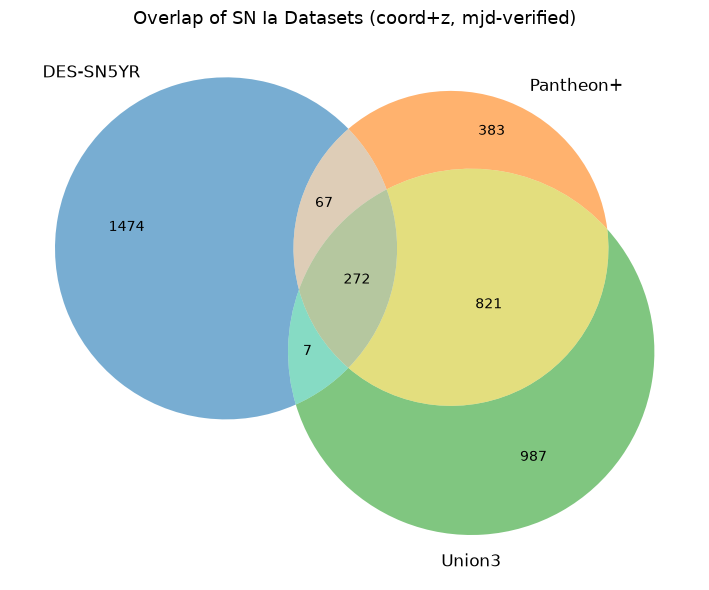

In [73]:
surveys_3 = ['DES', 'Pantheon+', 'Union3']

def venn_subset_count(survey_set):
    sv = set(survey_set)
    count = 0
    for phys_id, svs in phys_to_surveys.items():
        svs = svs & set(surveys_3)
        if svs == sv:
            count += 1
    return count

D_only = venn_subset_count({'DES'})
P_only = venn_subset_count({'Pantheon+'})
U_only = venn_subset_count({'Union3'})
Z_only = venn_subset_count({'ZTF'})
DP = venn_subset_count({'DES', 'Pantheon+'})
DU = venn_subset_count({'DES', 'Union3'})
PU = venn_subset_count({'Pantheon+', 'Union3'})
DZ = venn_subset_count({'DES', 'ZTF'})
UZ = venn_subset_count({'Union3', 'ZTF'})
PZ = venn_subset_count({'Pantheon+', 'ZTF'})
DPU = venn_subset_count({'DES', 'Pantheon+', 'Union3'})

fig, ax = plt.subplots(figsize=(8, 6))
v = venn3(
    subsets=(D_only, P_only, DP, U_only, DU, PU, DPU),
    set_labels=('DES-SN5YR', 'Pantheon+', 'Union3'),
    set_colors=('#1f77b4', '#ff7f0e', '#2ca02c'),
    alpha=0.6, ax=ax)
ax.set_title('Overlap of SN Ia Datasets (coord+z, mjd-verified)', fontsize=13)
plt.tight_layout()
plt.show()
   

In [74]:
print('=' * 60)
print('PAIRWISE OVERLAP (physical SNe, mjd-verified)')
print('=' * 60)
surveys_list = ['DES', 'ZTF', 'Pantheon+', 'Union3']

matrix = pd.DataFrame(0, index=surveys_list, columns=surveys_list)
for phys_id, svs in phys_to_surveys.items():
    for s1 in svs:
        for s2 in svs:
            if s1 != s2:
                matrix.loc[s1, s2] += 1

sizes = {'DES': len(des_m), 'ZTF': len(ztf_m),
         'Pantheon+': len(pan_m), 'Union3': len(uni_m)}
for s in surveys_list:
    matrix.loc[s, s] = sizes[s]
print(matrix.to_string())
print()

print('PAIRWISE OVERLAP (% of smaller dataset)')
pct_matrix = pd.DataFrame('', index=surveys_list, columns=surveys_list)
for i, s1 in enumerate(surveys_list):
    for j, s2 in enumerate(surveys_list):
        if i == j:
            pct_matrix.loc[s1, s2] = str(sizes[s1])
        elif i < j:
            cnt = matrix.loc[s1, s2]
            pct = 100 * cnt / min(sizes[s1], sizes[s2])
            pct_matrix.loc[s1, s2] = f'{cnt} ({pct:.1f}%)'
            pct_matrix.loc[s2, s1] = f'{cnt} ({pct:.1f}%)'
print(pct_matrix.to_string())

PAIRWISE OVERLAP (physical SNe, mjd-verified)
            DES   ZTF  Pantheon+  Union3
DES        1820     0        339     279
ZTF           0  3628          4      22
Pantheon+   339     4       1543    1093
Union3      279    22       1093    2087

PAIRWISE OVERLAP (% of smaller dataset)
                   DES        ZTF     Pantheon+        Union3
DES               1820   0 (0.0%)   339 (22.0%)   279 (15.3%)
ZTF           0 (0.0%)       3628      4 (0.3%)     22 (1.1%)
Pantheon+  339 (22.0%)   4 (0.3%)          1543  1093 (70.8%)
Union3     279 (15.3%)  22 (1.1%)  1093 (70.8%)          2087


In [75]:
print('=' * 55)
print('CROSS-MATCH SUMMARY')
print('=' * 55)
print(f'  Total SNe across all 4 datasets: {len(all_sne)}')
print(f'  Matches (coord+z, mjd-verified): {len(all_matches)}')
print()
print(f'  DES + Pantheon+:     {DP}')
print(f'  DES + Union3:        {DU}')
print(f'  Pantheon+ + Union3:  {PU}')
print(f'  All three:           {DPU}')
print()

CROSS-MATCH SUMMARY
  Total SNe across all 4 datasets: 9078
  Matches (coord+z, mjd-verified): 1731

  DES + Pantheon+:     67
  DES + Union3:        7
  Pantheon+ + Union3:  821
  All three:           272



Comparison data: 1731 matched SN pairs


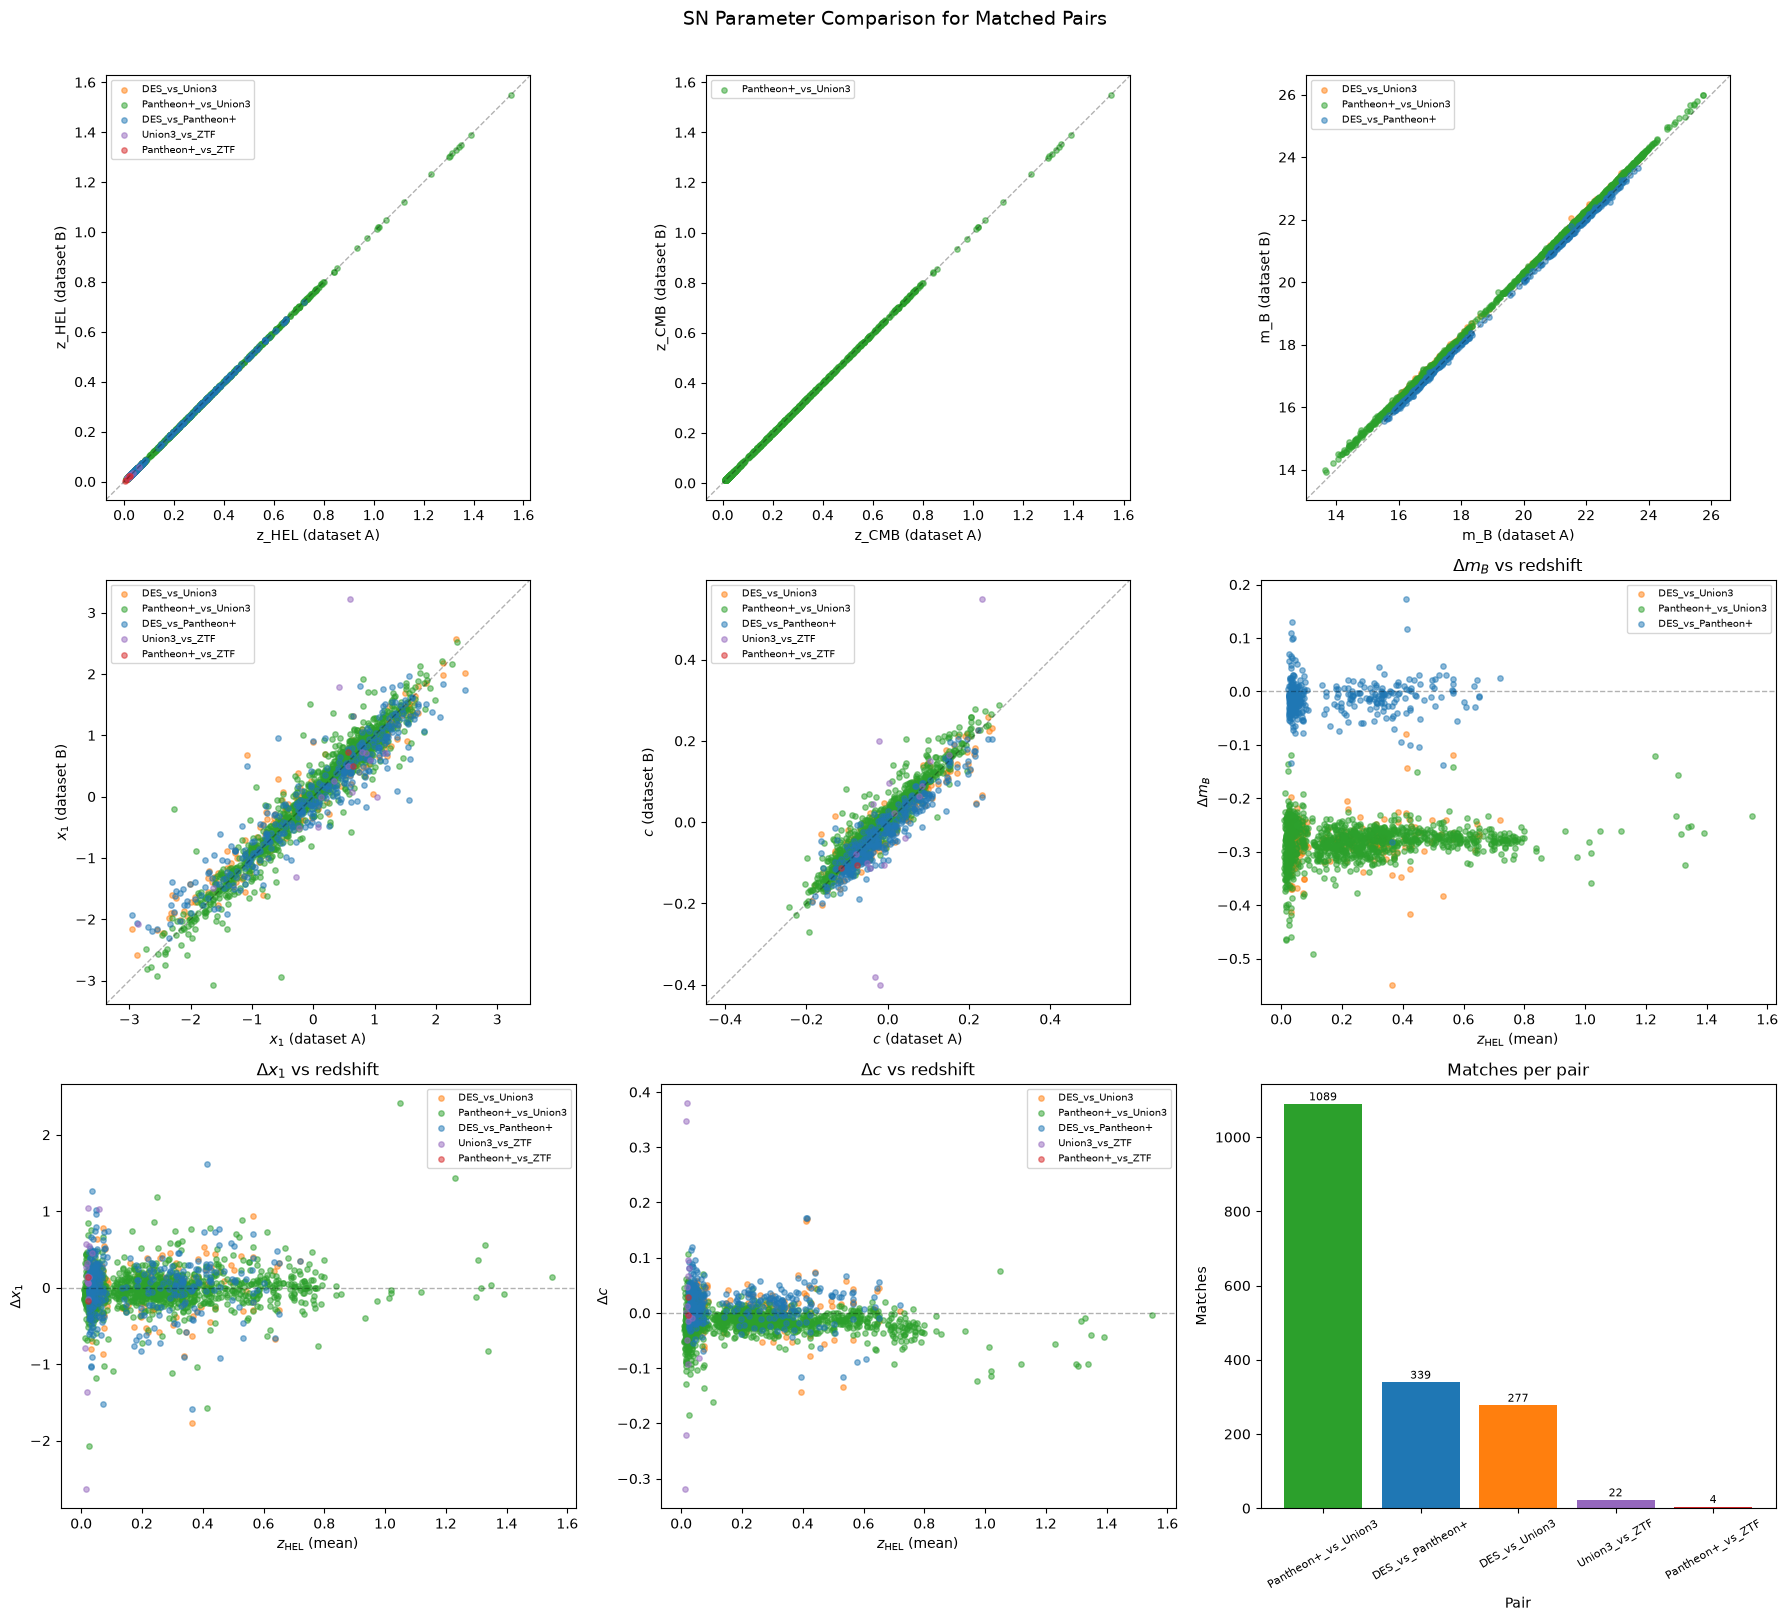

In [76]:
survey_lookup = {}

survey_lookup['DES'] = des_records.set_index('uid')[['z', 'zHEL', 'x1', 'c', 'mb']].rename(
    columns={'z': 'zhd', 'zHEL': 'zhel'}).to_dict('index')

pan_dedup = pan.drop_duplicates(subset='CID')
survey_lookup['Pantheon+'] = pan_dedup.set_index('CID')[
    ['zHD', 'zCMB', 'zHEL', 'mB', 'x1', 'c']
].rename(columns={'zHD': 'zhd', 'zCMB': 'zcmb', 'zHEL': 'zhel', 'mB': 'mb'}).to_dict('index')

names_from_paths = [p.split('/')[-1] for p in udata['snpaths']]
uid_to_idx = {uid: i for i, uid in enumerate(names_from_paths)}
uni_lookup = {}
for uid, idx in uid_to_idx.items():
    uni_lookup[uid] = {
        'zcmb': udata['z_CMB_list'][idx],
        'zhel': udata['z_helio_list'][idx],
        'mb': udata['mB_list'][idx],
        'x1': udata['x1_list'][idx],
        'c': udata['c_list'][idx],
    }
survey_lookup['Union3'] = uni_lookup

survey_lookup['ZTF'] = ztf_records.set_index('uid')[['z', 'x1', 'c']].rename(
    columns={'z': 'zhel'}).to_dict('index')

comp_rows = []
for _, row in all_matches.iterrows():
    pA = survey_lookup.get(row['survey_A'], {}).get(row['uid_A'], {})
    pB = survey_lookup.get(row['survey_B'], {}).get(row['uid_B'], {})
    if not pA or not pB:
        continue
    comp_rows.append({
        'pair': row['pair'],
        'zhel_A': pA.get('zhel', np.nan),
        'zhel_B': pB.get('zhel', np.nan),
        'zcmb_A': pA.get('zcmb', np.nan),
        'zcmb_B': pB.get('zcmb', np.nan),
        'mb_A': pA.get('mb', pA.get('mB', np.nan)),
        'mb_B': pB.get('mb', pB.get('mB', np.nan)),
        'x1_A': pA.get('x1', np.nan),
        'x1_B': pB.get('x1', np.nan),
        'c_A': pA.get('c', np.nan),
        'c_B': pB.get('c', np.nan),
    })
comp = pd.DataFrame(comp_rows)
print(f'Comparison data: {len(comp)} matched SN pairs')

comp['dmb'] = comp['mb_A'] - comp['mb_B']
comp['dx1'] = comp['x1_A'] - comp['x1_B']
comp['dc'] = comp['c_A'] - comp['c_B']
comp['zhel_mean'] = (comp['zhel_A'] + comp['zhel_B']) / 2

pair_colors = {
    'DES_vs_Pantheon+': '#1f77b4',
    'DES_vs_Union3': '#ff7f0e',
    'Pantheon+_vs_Union3': '#2ca02c',
    'Pantheon+_vs_ZTF': '#d62728',
    'Union3_vs_ZTF': '#9467bd',
    'DES_vs_ZTF': '#000000'
}

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle('SN Parameter Comparison for Matched Pairs', fontsize=14, y=1.01)

scatter_kw = dict(s=15, alpha=0.5)

scatter_params = [
    (0, 0, 'zhel_A', 'zhel_B', 'z_HEL (dataset A)', 'z_HEL (dataset B)'),
    (0, 1, 'zcmb_A', 'zcmb_B', 'z_CMB (dataset A)', 'z_CMB (dataset B)'),
    (0, 2, 'mb_A', 'mb_B', 'm_B (dataset A)', 'm_B (dataset B)'),
]
for r, c, xcol, ycol, xl, yl in scatter_params:
    ax = axes[r, c]
    valid = comp.dropna(subset=[xcol, ycol])
    if len(valid) == 0:
        ax.text(0.5, 0.5, f'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    for pn in valid['pair'].unique():
        sub = valid[valid['pair'] == pn]
        ax.scatter(sub[xcol], sub[ycol], color=pair_colors.get(pn, '#888'), **scatter_kw, label=pn)
    lo, hi = min(valid[xcol].min(), valid[ycol].min()), max(valid[xcol].max(), valid[ycol].max())
    margin = (hi - lo) * 0.05
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin], 'k--', alpha=0.3, lw=1)
    ax.set_xlim(lo - margin, hi + margin)
    ax.set_ylim(lo - margin, hi + margin)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='upper left')

for r, c, xcol, ycol, xl, yl in [
    (1, 0, 'x1_A', 'x1_B', '$x_1$ (dataset A)', '$x_1$ (dataset B)'),
    (1, 1, 'c_A', 'c_B', '$c$ (dataset A)', '$c$ (dataset B)'),
]:
    ax = axes[r, c]
    valid = comp.dropna(subset=[xcol, ycol])
    if len(valid) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    for pn in valid['pair'].unique():
        sub = valid[valid['pair'] == pn]
        ax.scatter(sub[xcol], sub[ycol], color=pair_colors.get(pn, '#888'), **scatter_kw, label=pn)
    lo, hi = min(valid[xcol].min(), valid[ycol].min()), max(valid[xcol].max(), valid[ycol].max())
    margin = (hi - lo) * 0.05
    ax.plot([lo - margin, hi + margin], [lo - margin, hi + margin], 'k--', alpha=0.3, lw=1)
    ax.set_xlim(lo - margin, hi + margin)
    ax.set_ylim(lo - margin, hi + margin)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='upper left')

ax = axes[1, 2]
valid = comp.dropna(subset=['dmb', 'zhel_mean'])
for pn in valid['pair'].unique():
    sub = valid[valid['pair'] == pn]
    ax.scatter(sub['zhel_mean'], sub['dmb'], color=pair_colors.get(pn, '#888'), **scatter_kw, label=pn)
ax.axhline(0, color='k', ls='--', alpha=0.3, lw=1)
ax.set_xlabel('$z_{\\rm HEL}$ (mean)')
ax.set_ylabel('$\\Delta m_B$')
ax.set_title('$\\Delta m_B$ vs redshift')
ax.legend(fontsize=7)

ax = axes[2, 0]
valid = comp.dropna(subset=['dx1', 'zhel_mean'])
for pn in valid['pair'].unique():
    sub = valid[valid['pair'] == pn]
    ax.scatter(sub['zhel_mean'], sub['dx1'], color=pair_colors.get(pn, '#888'), **scatter_kw, label=pn)
ax.axhline(0, color='k', ls='--', alpha=0.3, lw=1)
ax.set_xlabel('$z_{\\rm HEL}$ (mean)')
ax.set_ylabel('$\\Delta x_1$')
ax.set_title('$\\Delta x_1$ vs redshift')
ax.legend(fontsize=7)

ax = axes[2, 1]
valid = comp.dropna(subset=['dc', 'zhel_mean'])
for pn in valid['pair'].unique():
    sub = valid[valid['pair'] == pn]
    ax.scatter(sub['zhel_mean'], sub['dc'], color=pair_colors.get(pn, '#888'), **scatter_kw, label=pn)
ax.axhline(0, color='k', ls='--', alpha=0.3, lw=1)
ax.set_xlabel('$z_{\\rm HEL}$ (mean)')
ax.set_ylabel('$\\Delta c$')
ax.set_title('$\\Delta c$ vs redshift')
ax.legend(fontsize=7)

ax = axes[2, 2]
pair_counts = all_matches['pair'].value_counts()
ax.bar(pair_counts.index, pair_counts.values,
       color=[pair_colors.get(p, '#888') for p in pair_counts.index])
ax.set_xlabel('Pair')
ax.set_ylabel('Matches')
ax.set_title('Matches per pair')
ax.tick_params(axis='x', rotation=30, labelsize=8)
for i, v in enumerate(pair_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()
